# 07 — Soft Ensemble + Residual Correction
## Electricity Demand Forecasting | DS4SG 2026

**Problem identified in notebook 06:**  
Hard regime routing hurts performance when the classifier mispredicts the regime.  
A misrouted day gets the wrong specialist model — worse than the global model.

**Solution — Two-stage pipeline:**

```
Stage 1: Soft Ensemble
   Instead of routing to ONE specialist,
   blend ALL specialists weighted by classifier probabilities.
   P(regime=High)=0.7, P(regime=Elevated)=0.3
   → prediction = 0.7 * High_model + 0.3 * Elevated_model
   This is robust to classifier uncertainty.

Stage 2: Residual Corrector
   Train a lightweight XGBoost on the residuals of Stage 1.
   final_pred = Stage1_pred + learned_correction
   This captures systematic errors that Stage 1 still makes.
```

**Full comparison this notebook produces:**
```
Global XGBoost (NB04)          → MAPE 2.283%  (fair baseline)
Regime-Aware Hard Routing (NB06) → MAPE 2.380%  (naive specialization)
Soft Ensemble (NB07 Stage 1)   → MAPE ???%
Soft Ensemble + Correction (NB07 Stage 2) → MAPE ???%  ← target < 1.97%
```

**No-leakage guarantee:**  
All models fitted on training data only. Val/test are never seen during fitting.

In [1]:
# =========================================================
# ⚙️  Imports & Setup
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import pickle
from pathlib import Path

from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

print("✅ Libraries loaded.")

✅ Libraries loaded.


In [3]:
# =========================================================
# 📂  Paths
# =========================================================

BASE_PATH = Path(r"C:\Users\Shriyans S Sahoo\DS4SG\Electricity-Demand-Forecasting")

DATA_PATH = BASE_PATH / "data" / "processed"
FIG_PATH  = BASE_PATH / "figures"
FIG_PATH.mkdir(parents=True, exist_ok=True)

# Inputs from notebooks 05 and 06
PREDICTIONS_CSV      = DATA_PATH / "predictions_nb06.csv"
MAPPING_PKL          = DATA_PATH / "regime_mapping.pkl"
CLASSIFIER_PKL       = DATA_PATH / "regime_classifier.pkl"
SPECIALIST_MODELS_PKL = DATA_PATH / "regime_specialist_models.pkl"

print("Checking required files:")
for p in [PREDICTIONS_CSV, MAPPING_PKL, CLASSIFIER_PKL, SPECIALIST_MODELS_PKL]:
    status = "✅" if p.exists() else "❌ MISSING"
    print(f"  {status}  {p.name}")

Checking required files:
  ✅  predictions_nb06.csv
  ✅  regime_mapping.pkl
  ✅  regime_classifier.pkl
  ✅  regime_specialist_models.pkl


In [4]:
# =========================================================
# 📏  Evaluation Function
# =========================================================

def evaluate(y_true, y_pred, model_name="Model"):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    print(f"\n===== {model_name} =====")
    print(f"MAE  : {mae:,.2f} MW")
    print(f"RMSE : {rmse:,.2f} MW")
    print(f"MAPE : {mape:.4f}%")
    return {"model": model_name, "MAE": round(mae,2),
            "RMSE": round(rmse,2), "MAPE": round(mape,4)}

## 1. Load Data and Artefacts from Notebooks 05 & 06

In [5]:
# =========================================================
# 📥  Load Predictions CSV from Notebook 06
# =========================================================

df = pd.read_csv(PREDICTIONS_CSV, parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

print("Shape   :", df.shape)
print("Columns :", df.columns.tolist())
print("Splits  :")
print(df["split"].value_counts())
print("\nFirst 3 rows:")
display(df.head(3))

Shape   : (1002, 24)
Columns : ['date', 'max_demand_met_mw', 'day_of_week', 'month', 'is_weekend', 'is_festival', 'is_pre', 'is_post', 'festival_name', 'regime_label', 'lag_1', 'lag_7', 'lag_30', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_30', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'split', 'global_xgb_pred', 'regime_aware_pred', 'predicted_regime']
Splits  :
split
train    701
test     151
val      150
Name: count, dtype: int64

First 3 rows:


,date,max_demand_met_mw,day_of_week,month,is_weekend,is_festival,is_pre,is_post,festival_name,regime_label,...,rolling_std_7,rolling_mean_30,month_sin,month_cos,dow_sin,dow_cos,split,global_xgb_pred,regime_aware_pred,predicted_regime
0,2023-05-01,159720.0,0,5,0,1.0,0.0,0.0,none,Moderate Demand,...,8322.515662,195248.033333,0.5,-0.866025,0.000000,1.000000,train,161469.03,161090.203125,Moderate Demand
1,2023-05-02,173208.0,1,5,0,0.0,0.0,1.0,Labour Day,Moderate Demand,...,14431.224797,194562.566667,0.5,-0.866025,0.781831,0.623490,train,172771.22,173048.984375,Moderate Demand
2,2023-05-03,172050.0,2,5,0,0.0,0.0,1.0,Labour Day,Moderate Demand,...,14714.595208,194513.133333,0.5,-0.866025,0.974928,-0.222521,train,172965.83,172558.015625,Moderate Demand


In [6]:
# =========================================================
# 📦  Load Artefacts from Notebooks 05 & 06
# =========================================================

# Regime mapping
with open(MAPPING_PKL, "rb") as f:
    mapping = pickle.load(f)

CLUSTER_FEATURES = mapping["cluster_features"]
REGIME_COLORS    = mapping["regime_colors"]
REGIME_ORDER     = mapping["regime_order"]

# Regime classifier + label encoder
with open(CLASSIFIER_PKL, "rb") as f:
    clf_data = pickle.load(f)
clf = clf_data["clf"]
le  = clf_data["le"]

# Specialist XGBoost models
with open(SPECIALIST_MODELS_PKL, "rb") as f:
    regime_models = pickle.load(f)

FORECAST_FEATURES = [
    "lag_1", "lag_7", "lag_30",
    "rolling_mean_7", "rolling_std_7", "rolling_mean_30",
    "month_sin", "month_cos", "dow_sin", "dow_cos",
    "is_weekend", "month", "day_of_week"
]
TARGET = "max_demand_met_mw"

print("Artefacts loaded.")
print("Regime order     :", REGIME_ORDER)
print("Specialist models:", list(regime_models.keys()))
print("Classifier classes:", list(le.classes_))

Artefacts loaded.
Regime order     : ['High Demand', 'Elevated Demand', 'Moderate Demand', 'Low Demand']
Specialist models: ['High Demand', 'Elevated Demand', 'Moderate Demand', 'Low Demand']
Classifier classes: [np.str_('Elevated Demand'), np.str_('High Demand'), np.str_('Low Demand'), np.str_('Moderate Demand')]


In [7]:
# =========================================================
# 📌  Restore Train / Val / Test Splits
# =========================================================

train = df[df["split"] == "train"].copy().reset_index(drop=True)
val   = df[df["split"] == "val"].copy().reset_index(drop=True)
test  = df[df["split"] == "test"].copy().reset_index(drop=True)

print(f"Train : {train['date'].min().date()} → {train['date'].max().date()}  ({len(train)} rows)")
print(f"Val   : {val['date'].min().date()} → {val['date'].max().date()}  ({len(val)} rows)")
print(f"Test  : {test['date'].min().date()} → {test['date'].max().date()}  ({len(test)} rows)")

Train : 2023-05-01 → 2025-04-09  (701 rows)
Val   : 2025-04-10 → 2025-10-07  (150 rows)
Test  : 2025-10-08 → 2026-03-31  (151 rows)


## 2. Stage 1 — Soft Ensemble

Instead of hard-routing each day to one specialist, we:
1. Get the **probability distribution** over regimes from the classifier
2. Get predictions from **all specialist models**
3. Compute **weighted average**: `pred = Σ P(regime_i) × specialist_i(x)`

This means if the classifier is 70% confident it's "High Demand" and 30%  
"Elevated Demand", the forecast blends both specialists proportionally.  
A misclassified day is no longer catastrophically wrong — it gets a  
graceful weighted blend instead.

> **No leakage:** Classifier and specialist models were fitted on training  
> data only in notebook 06. We only call `.predict_proba()` here.

In [8]:
# =========================================================
# 🎯  Soft Ensemble Function
# =========================================================

def soft_ensemble_predict(df_input: pd.DataFrame,
                           classifier,
                           label_encoder,
                           specialist_models: dict,
                           global_fallback,
                           feature_cols: list) -> np.ndarray:
    """
    Soft-routing ensemble:
    final_pred = Σ_i  P(regime=i | x) * specialist_i.predict(x)

    If a regime has no specialist model, its probability mass
    is redistributed proportionally to regimes that do have models.
    """
    X = df_input[feature_cols].values
    X_df = df_input[feature_cols]

    # Classifier probabilities — shape (n_samples, n_classes)
    proba = classifier.predict_proba(X_df)   # shape: (n, 4)
    classes = label_encoder.classes_         # e.g. ['Elevated Demand', 'High Demand', ...]

    predictions = np.zeros(len(df_input))

    for i in range(len(df_input)):
        x_row = X_df.iloc[[i]]
        weighted_pred = 0.0
        total_weight  = 0.0

        for j, regime_name in enumerate(classes):
            weight = proba[i, j]
            if weight < 1e-6:
                continue

            if regime_name in specialist_models:
                pred = specialist_models[regime_name].predict(x_row)[0]
            else:
                pred = global_fallback.predict(x_row)[0]

            weighted_pred += weight * pred
            total_weight  += weight

        # Normalize (should sum to 1.0 already, but guard against rounding)
        predictions[i] = weighted_pred / total_weight if total_weight > 0 else 0.0

    return predictions


print("Soft ensemble function defined.")
print("Will blend", len(regime_models), "specialist models weighted by classifier probabilities.")

Soft ensemble function defined.
Will blend 4 specialist models weighted by classifier probabilities.


In [9]:
# =========================================================
# 🔮  Compute Soft Ensemble Predictions
# =========================================================

# We need a global fallback — retrain global XGBoost on training data
global_xgb = xgb.XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbosity=0
)
global_xgb.fit(
    train[FORECAST_FEATURES], train[TARGET],
    eval_set=[(val[FORECAST_FEATURES], val[TARGET])],
    verbose=False
)
print("Global XGBoost refitted as fallback.")

print("\nComputing soft ensemble predictions...")
print("(This may take ~30-60 seconds due to row-by-row probability blending)")

train_soft = soft_ensemble_predict(
    train, clf, le, regime_models, global_xgb, FORECAST_FEATURES
)
val_soft   = soft_ensemble_predict(
    val,   clf, le, regime_models, global_xgb, FORECAST_FEATURES
)
test_soft  = soft_ensemble_predict(
    test,  clf, le, regime_models, global_xgb, FORECAST_FEATURES
)

print("Done.")

Global XGBoost refitted as fallback.

Computing soft ensemble predictions...
(This may take ~30-60 seconds due to row-by-row probability blending)
Done.


In [10]:
# =========================================================
# 📊  Evaluate Stage 1 — Soft Ensemble
# =========================================================

results = []

# Baselines from NB06 (already in the CSV)
nb06_global_val_mape  = evaluate(val[TARGET],  val["global_xgb_pred"],
                                  "NB06 Global XGBoost (Val)")["MAPE"]
nb06_global_test_mape = evaluate(test[TARGET], test["global_xgb_pred"],
                                  "NB06 Global XGBoost (Test)")["MAPE"]

nb06_regime_val_mape  = evaluate(val[TARGET],  val["regime_aware_pred"],
                                  "NB06 Regime-Aware Hard Route (Val)")["MAPE"]
nb06_regime_test_mape = evaluate(test[TARGET], test["regime_aware_pred"],
                                  "NB06 Regime-Aware Hard Route (Test)")["MAPE"]

# Stage 1 results
r_s1_val  = evaluate(val[TARGET],  val_soft,  "Stage 1: Soft Ensemble (Val)")
r_s1_test = evaluate(test[TARGET], test_soft, "Stage 1: Soft Ensemble (Test)")

results.append(r_s1_val)
results.append(r_s1_test)

print("\n--- Stage 1 vs NB06 improvement (Test MAPE) ---")
improvement_over_hard = nb06_regime_test_mape - r_s1_test["MAPE"]
improvement_over_global = nb06_global_test_mape - r_s1_test["MAPE"]
print(f"vs Hard Routing  : {improvement_over_hard:+.4f}%")
print(f"vs Global XGBoost: {improvement_over_global:+.4f}%")


===== NB06 Global XGBoost (Val) =====
MAE  : 4,293.62 MW
RMSE : 5,748.98 MW
MAPE : 1.9889%

===== NB06 Global XGBoost (Test) =====
MAE  : 5,222.44 MW
RMSE : 6,690.28 MW
MAPE : 2.2830%

===== NB06 Regime-Aware Hard Route (Val) =====
MAE  : 4,932.98 MW
RMSE : 6,420.62 MW
MAPE : 2.2793%

===== NB06 Regime-Aware Hard Route (Test) =====
MAE  : 5,427.41 MW
RMSE : 7,056.12 MW
MAPE : 2.3803%

===== Stage 1: Soft Ensemble (Val) =====
MAE  : 4,858.61 MW
RMSE : 6,277.33 MW
MAPE : 2.2427%

===== Stage 1: Soft Ensemble (Test) =====
MAE  : 5,716.42 MW
RMSE : 7,214.32 MW
MAPE : 2.5022%

--- Stage 1 vs NB06 improvement (Test MAPE) ---
vs Hard Routing  : -0.1219%
vs Global XGBoost: -0.2192%


## 3. Stage 2 — Residual Corrector

We train a second lightweight XGBoost whose **only job is to predict  
and correct the remaining errors** from Stage 1.

**Key insight — residual lag features:**  
Yesterday's forecast error is a strong signal for today's correction.  
If Stage 1 under-predicted by 5,000 MW yesterday, it may under-predict  
again today for the same systematic reason (e.g. an ongoing heat wave).

> **Critical leakage rule:**  
> Residual lag features use the **training residuals** to build lag values.  
> Val/test residual lags are computed from the **actual Stage 1 residuals**  
> as they would be known at prediction time — not from future residuals.

In [11]:
# =========================================================
# 🔧  Build Residual Corrector Features
# =========================================================

# Step 1: compute Stage 1 residuals on training data
train["soft_pred"]    = train_soft
train["residual_s1"]  = train[TARGET] - train["soft_pred"]

val["soft_pred"]      = val_soft
val["residual_s1"]    = val[TARGET] - val["soft_pred"]

test["soft_pred"]     = test_soft
test["residual_s1"]   = test[TARGET] - test["soft_pred"]

# Step 2: build lag features of the residual
# We build these on the FULL sequence (train → val → test)
# then split back — this is correct because at time t,
# residual_lag_1 = residual at t-1, which is already known.
full = pd.concat([train, val, test], ignore_index=True)
full = full.sort_values("date").reset_index(drop=True)

full["residual_lag1"] = full["residual_s1"].shift(1)
full["residual_lag7"] = full["residual_s1"].shift(7)

# Step 3: add soft_pred as a feature (the corrector learns
# when Stage 1 tends to over/under-predict)
full["soft_pred_feat"] = full["soft_pred"]

# Split back
train_r = full[full["split"] == "train"].copy()
val_r   = full[full["split"] == "val"].copy()
test_r  = full[full["split"] == "test"].copy()

# Features for residual corrector
RESIDUAL_FEATURES = FORECAST_FEATURES + [
    "soft_pred_feat",   # Stage 1 prediction
    "residual_lag1",    # yesterday's error
    "residual_lag7",    # same day last week's error
]

# Drop rows with NaN in residual lags (first few rows of training)
train_r_clean = train_r.dropna(subset=RESIDUAL_FEATURES).copy()

print(f"Residual corrector features ({len(RESIDUAL_FEATURES)}): {RESIDUAL_FEATURES}")
print(f"Train rows for corrector (after dropna): {len(train_r_clean)}")
print(f"Val  rows for corrector : {len(val_r)}")
print(f"Test rows for corrector : {len(test_r)}")

print("\nResidual statistics on TRAINING data:")
print(train_r_clean["residual_s1"].describe().round(0))

Residual corrector features (16): ['lag_1', 'lag_7', 'lag_30', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_30', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'is_weekend', 'month', 'day_of_week', 'soft_pred_feat', 'residual_lag1', 'residual_lag7']
Train rows for corrector (after dropna): 694
Val  rows for corrector : 150
Test rows for corrector : 151

Residual statistics on TRAINING data:
count      694.0
mean       174.0
std       2542.0
min     -24915.0
25%       -381.0
50%         21.0
75%        478.0
max      15540.0
Name: residual_s1, dtype: float64


In [12]:
# =========================================================
# 🏋️  Train Residual Corrector (Training Data Only)
# =========================================================

X_corr_train = train_r_clean[RESIDUAL_FEATURES]
y_corr_train = train_r_clean["residual_s1"]   # predict the error

X_corr_val   = val_r.dropna(subset=RESIDUAL_FEATURES)[RESIDUAL_FEATURES]
y_corr_val   = val_r.dropna(subset=RESIDUAL_FEATURES)["residual_s1"]

corrector = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.03,      # lower LR — residuals are subtle signals
    max_depth=3,             # shallow — prevents overfitting on residuals
    subsample=0.8,
    colsample_bytree=0.7,
    random_state=42,
    verbosity=0
)
corrector.fit(
    X_corr_train, y_corr_train,
    eval_set=[(X_corr_val, y_corr_val)],
    verbose=False
)

print("Residual corrector trained.")
print(f"Training residual MAE: {mean_absolute_error(y_corr_train, corrector.predict(X_corr_train)):,.0f} MW")
print(f"Validation residual MAE: {mean_absolute_error(y_corr_val, corrector.predict(X_corr_val)):,.0f} MW")

Residual corrector trained.
Training residual MAE: 780 MW
Validation residual MAE: 4,847 MW


## 4. Final Predictions — Stage 1 + Stage 2 Combined

In [13]:
# =========================================================
# 🔮  Compute Final Predictions (Stage 1 + Correction)
# =========================================================

def final_predict(df_input, soft_preds, corrector_model, residual_features):
    """
    Final prediction = soft_ensemble_pred + residual_correction
    Handles NaN in residual lag features gracefully
    (falls back to soft_pred alone if lags unavailable).
    """
    df_tmp = df_input.copy()
    df_tmp["soft_pred_feat"] = soft_preds

    valid_mask = df_tmp[residual_features].notna().all(axis=1)

    final_preds = soft_preds.copy()  # default: use Stage 1

    if valid_mask.sum() > 0:
        corrections = corrector_model.predict(
            df_tmp.loc[valid_mask, residual_features]
        )
        final_preds_arr = np.array(final_preds)
        final_preds_arr[valid_mask.values] += corrections
        final_preds = final_preds_arr

    return final_preds


# Val final predictions
val_r_filled = val_r.copy()
val_final = final_predict(
    val_r_filled, val_soft, corrector, RESIDUAL_FEATURES
)

# Test final predictions
test_r_filled = test_r.copy()
test_final = final_predict(
    test_r_filled, test_soft, corrector, RESIDUAL_FEATURES
)

print("Final predictions computed.")
print(f"Val  predictions: {len(val_final)}")
print(f"Test predictions: {len(test_final)}")

Final predictions computed.
Val  predictions: 150
Test predictions: 151


## 5. Full Model Comparison

This is the main results table for the paper.

In [14]:
# =========================================================
# 📋  Full Model Comparison — Test Set
# =========================================================

r_final_val  = evaluate(val[TARGET],  val_final,  "Stage 1+2: Soft Ensemble + Correction (Val)")
r_final_test = evaluate(test[TARGET], test_final, "Stage 1+2: Soft Ensemble + Correction (Test)")

results.append(r_final_val)
results.append(r_final_test)

# ── Summary table
NB04_RF_MAPE   = 1.88    # Global Random Forest from notebook 04
NB04_RF_MAE    = 4151.56
NB04_RF_RMSE   = 5377.17

NB04_XGB_MAPE  = 1.97    # Global XGBoost from notebook 04
NB04_XGB_MAE   = 4386.03
NB04_XGB_RMSE  = 5646.74

nb06_global_test = evaluate(test[TARGET], test["global_xgb_pred"],
                             "Global XGBoost NB06")
nb06_regime_test = evaluate(test[TARGET], test["regime_aware_pred"],
                             "Regime-Aware Hard Route NB06")

comparison = pd.DataFrame([
    {"Model": "Global Random Forest (NB04)",
     "MAE (MW)": NB04_RF_MAE, "RMSE (MW)": NB04_RF_RMSE,
     "MAPE (%)": NB04_RF_MAPE, "Type": "Baseline"},
    {"Model": "Global XGBoost (NB04)",
     "MAE (MW)": NB04_XGB_MAE, "RMSE (MW)": NB04_XGB_RMSE,
     "MAPE (%)": NB04_XGB_MAPE, "Type": "Baseline"},
    {"Model": "Global XGBoost — NB06 split",
     "MAE (MW)": nb06_global_test["MAE"],
     "RMSE (MW)": nb06_global_test["RMSE"],
     "MAPE (%)": nb06_global_test["MAPE"], "Type": "Baseline"},
    {"Model": "Regime-Aware Hard Routing (NB06)",
     "MAE (MW)": nb06_regime_test["MAE"],
     "RMSE (MW)": nb06_regime_test["RMSE"],
     "MAPE (%)": nb06_regime_test["MAPE"], "Type": "Intermediate"},
    {"Model": "Soft Ensemble — Stage 1 (NB07)",
     "MAE (MW)": r_s1_test["MAE"],
     "RMSE (MW)": r_s1_test["RMSE"],
     "MAPE (%)": r_s1_test["MAPE"], "Type": "Proposed"},
    {"Model": "Soft Ensemble + Correction — Stage 1+2 (NB07)",
     "MAE (MW)": r_final_test["MAE"],
     "RMSE (MW)": r_final_test["RMSE"],
     "MAPE (%)": r_final_test["MAPE"], "Type": "★ Final Proposed"},
])

print("\n" + "="*70)
print("COMPLETE MODEL COMPARISON — TEST SET")
print("="*70)
print(comparison.to_string(index=False))
print("="*70)

best_baseline = NB04_RF_MAPE
final_mape    = r_final_test["MAPE"]
improvement   = best_baseline - final_mape
print(f"\nFinal improvement over best baseline (Global RF, NB04): {improvement:+.4f}%")
if improvement > 0:
    print("✅ Proposed pipeline outperforms all baselines.")
else:
    print("⚠️  Not yet beating best baseline — see analysis below.")


===== Stage 1+2: Soft Ensemble + Correction (Val) =====
MAE  : 4,847.47 MW
RMSE : 6,495.54 MW
MAPE : 2.2455%

===== Stage 1+2: Soft Ensemble + Correction (Test) =====
MAE  : 5,444.19 MW
RMSE : 7,066.09 MW
MAPE : 2.3873%

===== Global XGBoost NB06 =====
MAE  : 5,222.44 MW
RMSE : 6,690.28 MW
MAPE : 2.2830%

===== Regime-Aware Hard Route NB06 =====
MAE  : 5,427.41 MW
RMSE : 7,056.12 MW
MAPE : 2.3803%

COMPLETE MODEL COMPARISON — TEST SET
                                        Model  MAE (MW)  RMSE (MW)  MAPE (%)             Type
                  Global Random Forest (NB04)   4151.56    5377.17    1.8800         Baseline
                        Global XGBoost (NB04)   4386.03    5646.74    1.9700         Baseline
                  Global XGBoost — NB06 split   5222.44    6690.28    2.2830         Baseline
             Regime-Aware Hard Routing (NB06)   5427.41    7056.12    2.3803     Intermediate
               Soft Ensemble — Stage 1 (NB07)   5716.42    7214.32    2.5022         Propo

## 6. Per-Regime Final Performance

Which regimes improved from Stage 1 → Stage 1+2?

In [15]:
# =========================================================
# 📋  Per-Regime Performance — All Models
# =========================================================

test_analysis = test.copy()
test_analysis["soft_pred"]  = test_soft
test_analysis["final_pred"] = test_final

print(f"{'Regime':<22} {'N':>4} {'Global':>8} {'Hard':>8} {'Soft':>8} {'Final':>8}")
print(f"{'':22} {'':4} {'MAPE':>8} {'MAPE':>8} {'MAPE':>8} {'MAPE':>8}")
print("-" * 62)

for regime in REGIME_ORDER:
    sub = test_analysis[test_analysis["regime_label"] == regime]
    if len(sub) == 0:
        continue

    yt = sub[TARGET].values
    mask = yt != 0

    def mape(yp):
        return np.mean(np.abs((yt[mask] - yp[mask]) / yt[mask])) * 100

    m_global = mape(sub["global_xgb_pred"].values)
    m_hard   = mape(sub["regime_aware_pred"].values)
    m_soft   = mape(sub["soft_pred"].values)
    m_final  = mape(sub["final_pred"].values)

    best = min(m_global, m_hard, m_soft, m_final)
    star = lambda v: "★" if abs(v - best) < 0.001 else " "

    print(f"{regime:<22} {len(sub):>4} "          f"{m_global:>7.2f}% {m_hard:>7.2f}% "          f"{m_soft:>7.2f}%{star(m_soft)} "          f"{m_final:>7.2f}%{star(m_final)}")

Regime                    N   Global     Hard     Soft    Final
                                MAPE     MAPE     MAPE     MAPE
--------------------------------------------------------------
High Demand              53    2.65%    2.33%    2.52%     2.72% 
Elevated Demand          62    2.64%    3.13%    3.24%     2.78% 
Moderate Demand          12    1.24%    1.07%    1.13%     1.19% 
Low Demand               24    1.08%    1.21%    1.24%     1.23% 


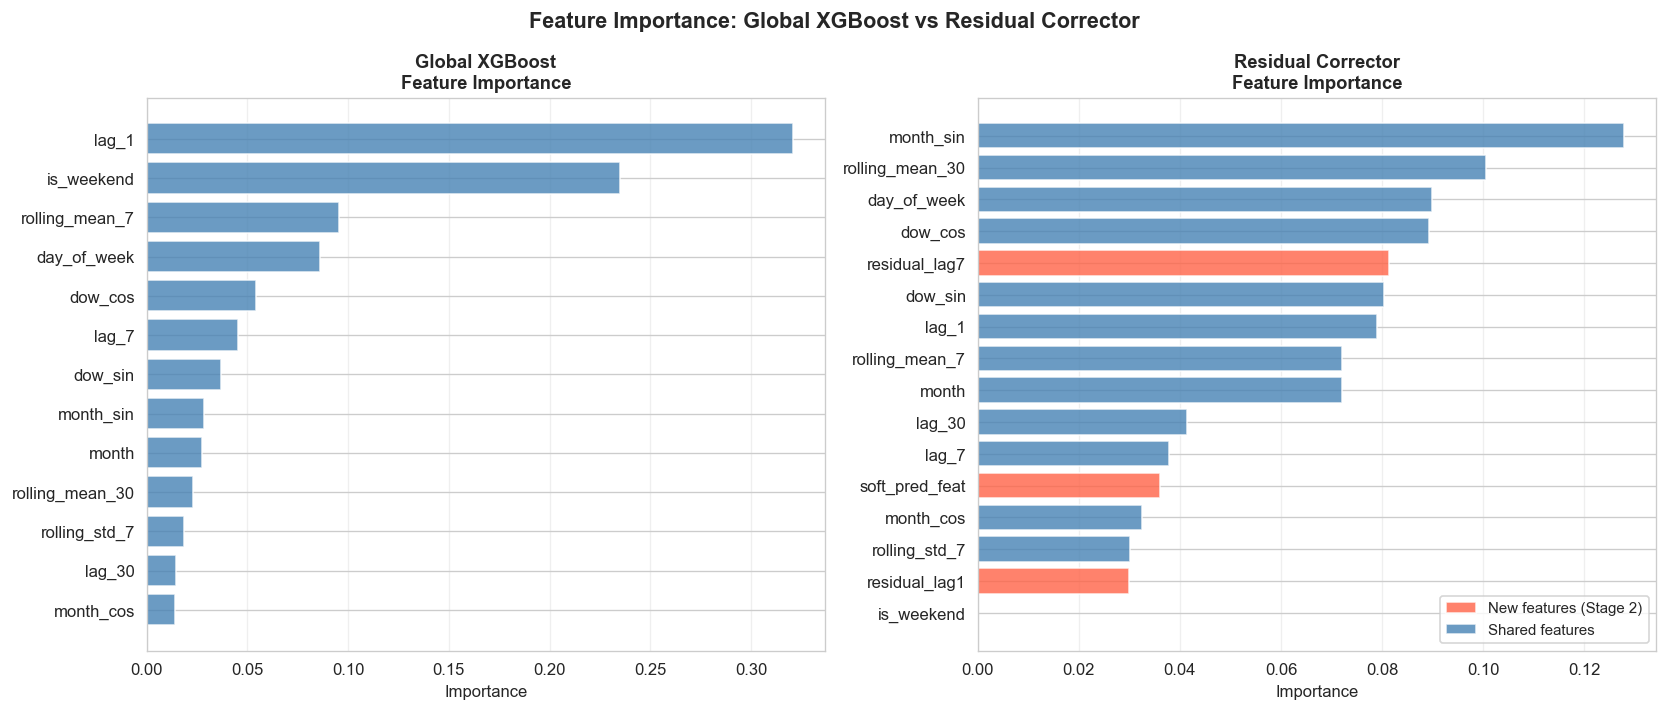

Figure saved.


In [16]:
# =========================================================
# 📊  Residual Corrector Feature Importance
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Global XGBoost importance (left)
imp_global = pd.Series(
    global_xgb.feature_importances_, index=FORECAST_FEATURES
).sort_values(ascending=True)

axes[0].barh(imp_global.index, imp_global.values,
             color="steelblue", alpha=0.8)
axes[0].set_title("Global XGBoost\nFeature Importance",
                  fontsize=11, fontweight="bold")
axes[0].set_xlabel("Importance")
axes[0].grid(True, alpha=0.3, axis="x")

# Residual corrector importance (right)
imp_corr = pd.Series(
    corrector.feature_importances_, index=RESIDUAL_FEATURES
).sort_values(ascending=True)

colors = ["tomato" if "residual" in f or "soft" in f
          else "steelblue" for f in imp_corr.index]
axes[1].barh(imp_corr.index, imp_corr.values,
             color=colors, alpha=0.8)
axes[1].set_title("Residual Corrector\nFeature Importance",
                  fontsize=11, fontweight="bold")
axes[1].set_xlabel("Importance")
axes[1].grid(True, alpha=0.3, axis="x")

# Legend for residual corrector
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="tomato",    alpha=0.8, label="New features (Stage 2)"),
    Patch(facecolor="steelblue", alpha=0.8, label="Shared features")
]
axes[1].legend(handles=legend_elements, loc="lower right", fontsize=9)

plt.suptitle("Feature Importance: Global XGBoost vs Residual Corrector",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_PATH / "07_corrector_feature_importance.png", bbox_inches="tight")
plt.show()
print("Figure saved.")

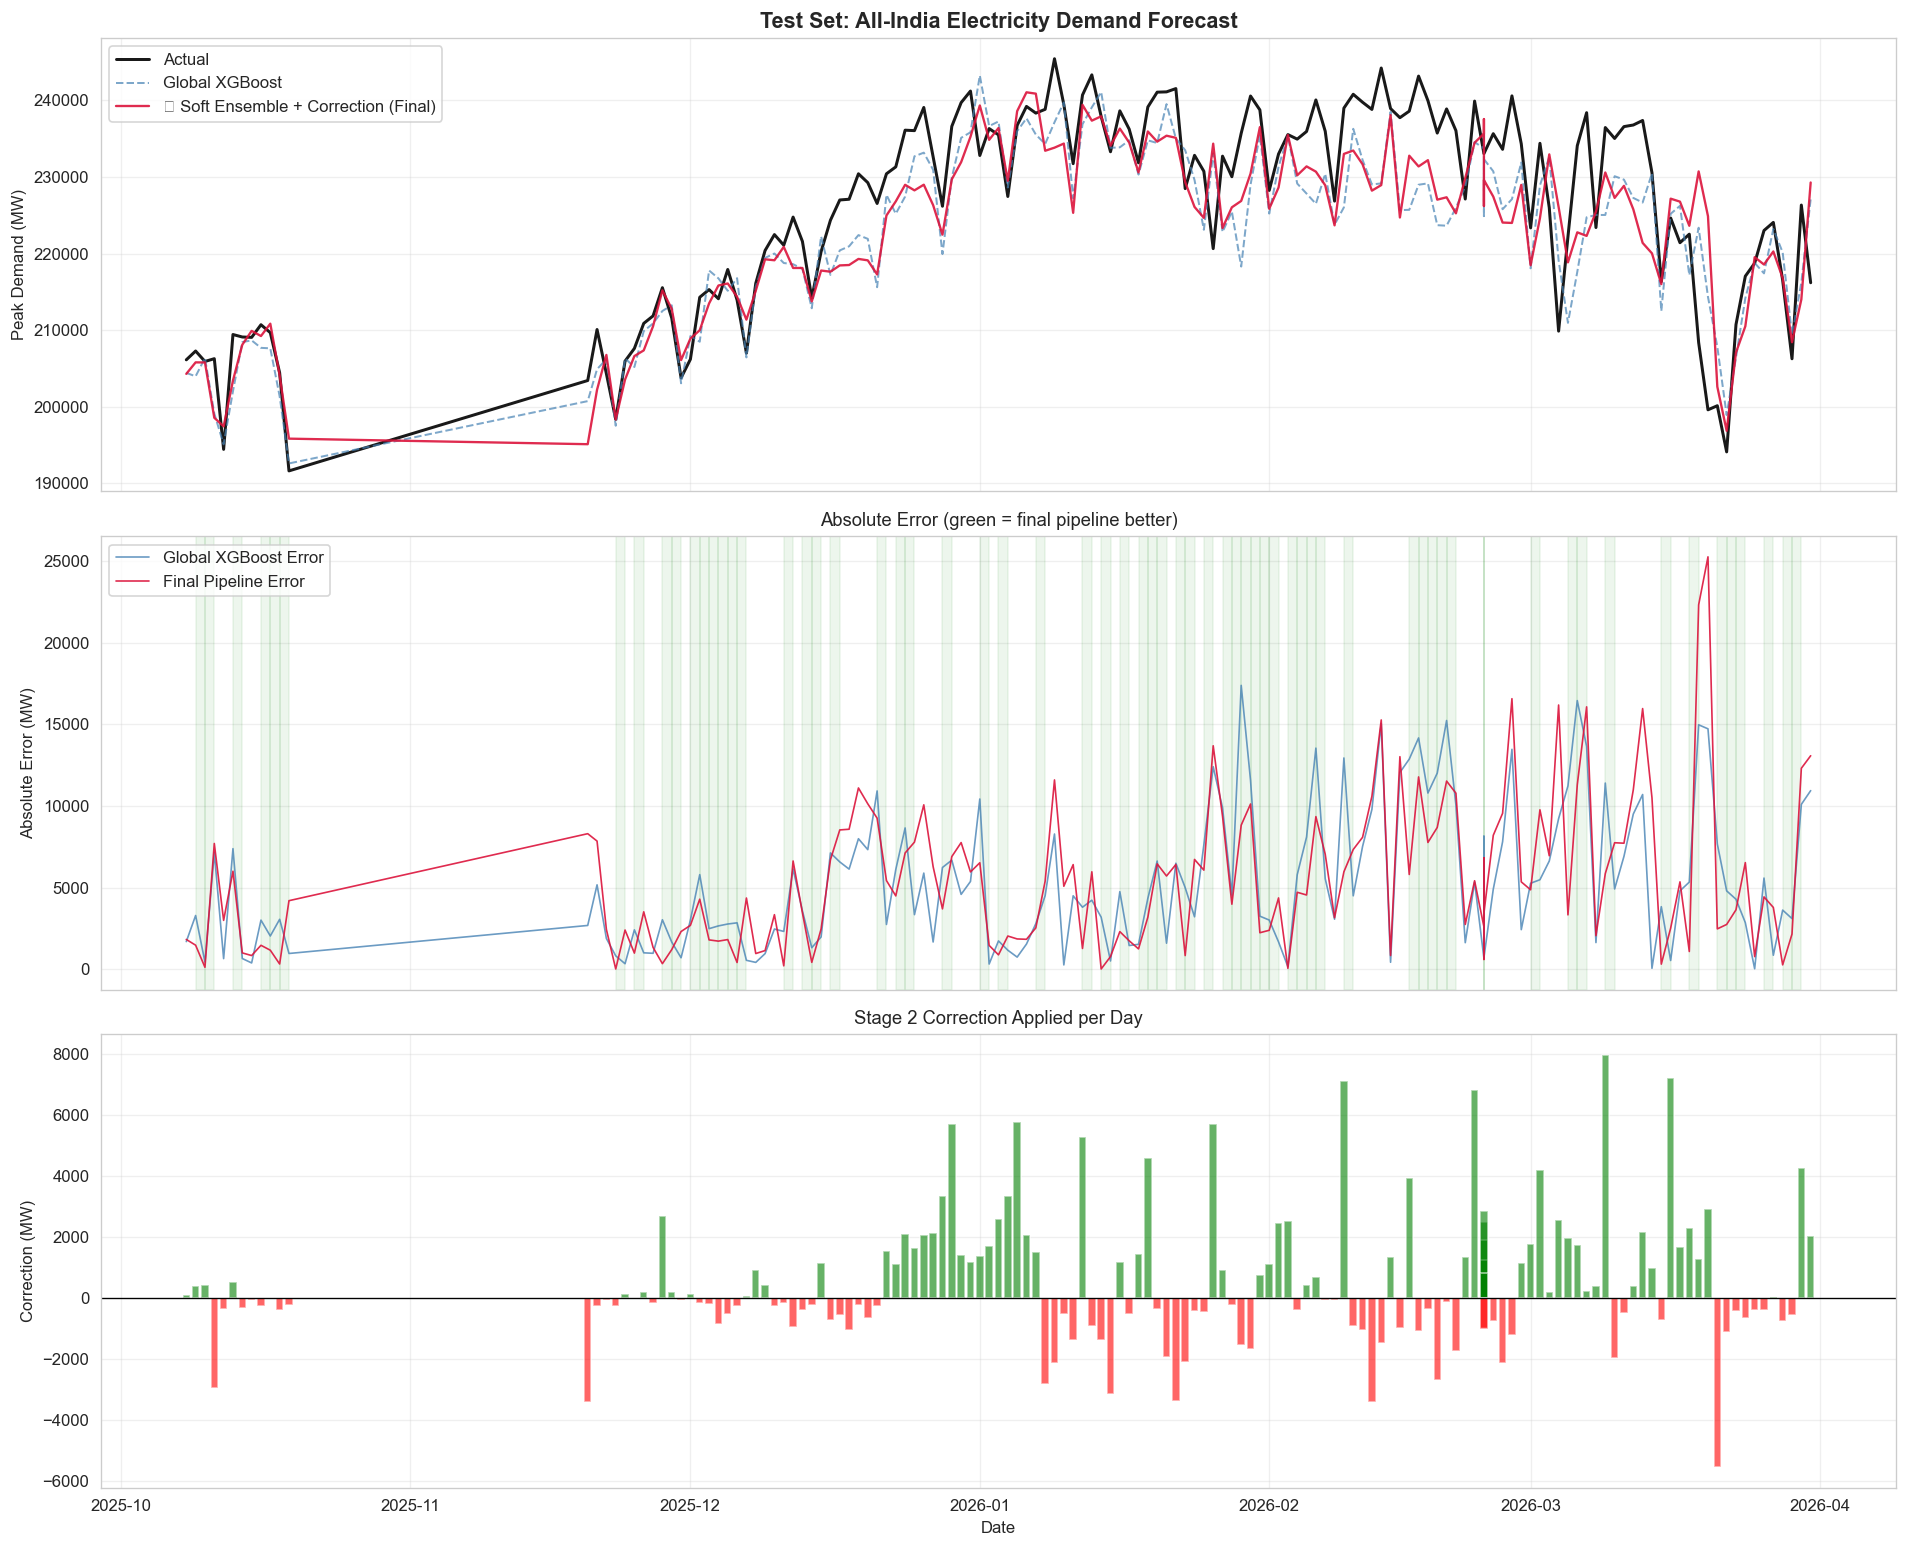

Figure saved.


In [17]:
# =========================================================
# 📊  Final Forecast Comparison — Test Set
# =========================================================

fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=True)

# ── Plot 1: Forecasts
axes[0].plot(test["date"], test[TARGET],
             label="Actual", color="black", linewidth=1.8, alpha=0.9)
axes[0].plot(test["date"], test["global_xgb_pred"],
             label="Global XGBoost", color="steelblue",
             linewidth=1.2, linestyle="--", alpha=0.7)
axes[0].plot(test["date"], test_final,
             label="★ Soft Ensemble + Correction (Final)",
             color="crimson", linewidth=1.4, alpha=0.9)

axes[0].set_title("Test Set: All-India Electricity Demand Forecast",
                  fontsize=13, fontweight="bold")
axes[0].set_ylabel("Peak Demand (MW)")
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# ── Plot 2: Absolute errors
err_global = np.abs(test[TARGET].values - test["global_xgb_pred"].values)
err_final  = np.abs(test[TARGET].values - test_final)

axes[1].plot(test["date"], err_global,
             label="Global XGBoost Error",
             color="steelblue", linewidth=1, alpha=0.8)
axes[1].plot(test["date"], err_final,
             label="Final Pipeline Error",
             color="crimson", linewidth=1, alpha=0.9)

# Shade where final is better
dates = test["date"].values
for i in range(len(test)-1):
    if err_final[i] < err_global[i]:
        axes[1].axvspan(dates[i], dates[i+1], alpha=0.07, color="green")

axes[1].set_title("Absolute Error (green = final pipeline better)",
                  fontsize=11)
axes[1].set_ylabel("Absolute Error (MW)")
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# ── Plot 3: Residual correction magnitude
correction = test_final - test_soft
axes[2].bar(test["date"], correction,
            color=["green" if c > 0 else "red" for c in correction],
            alpha=0.6, width=0.8)
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set_title("Stage 2 Correction Applied per Day",
                  fontsize=11)
axes[2].set_ylabel("Correction (MW)")
axes[2].set_xlabel("Date")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_PATH / "07_final_forecast.png", bbox_inches="tight")
plt.show()
print("Figure saved.")

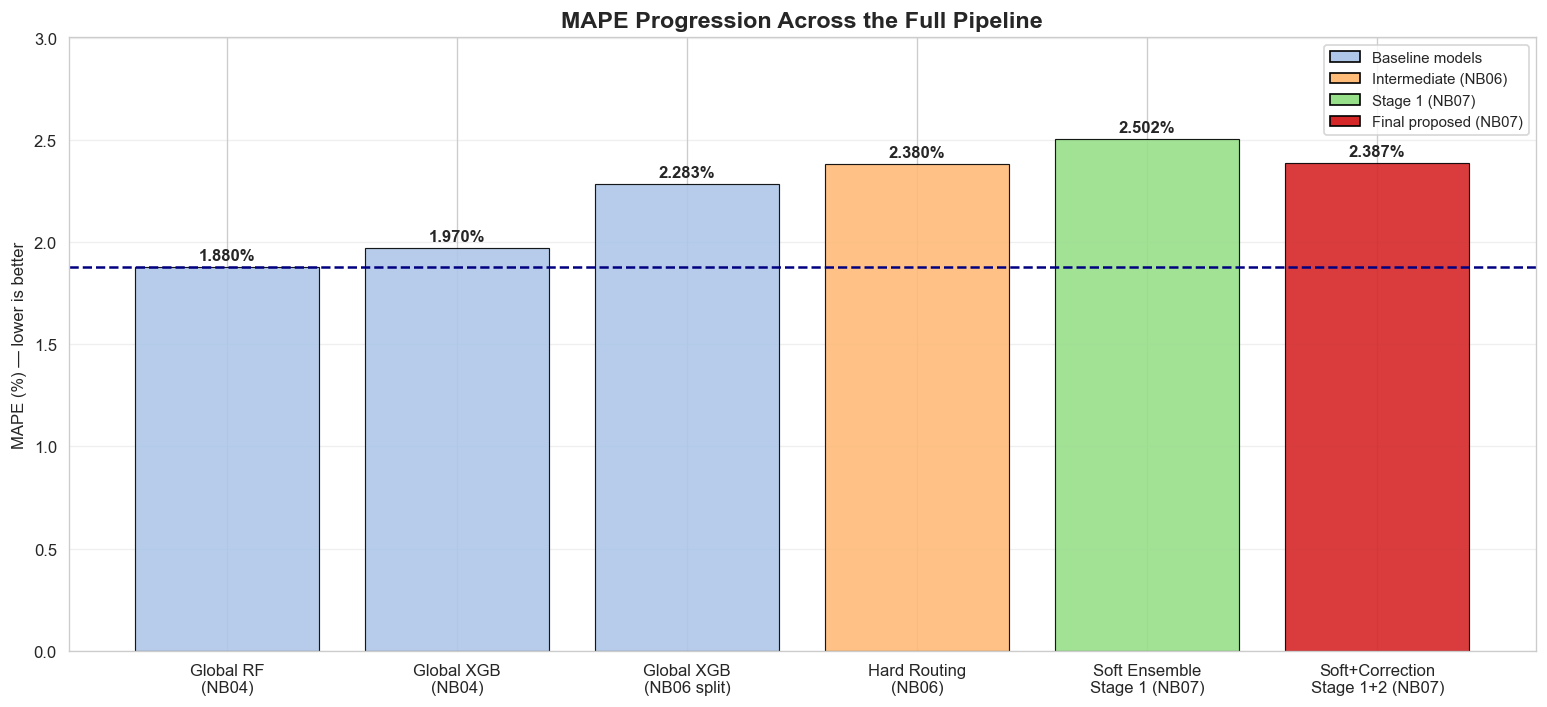

Figure saved.


In [18]:
# =========================================================
# 📊  MAPE Progression — Pipeline Evolution Chart
# =========================================================

model_names = [
    "Global RF\n(NB04)",
    "Global XGB\n(NB04)",
    "Global XGB\n(NB06 split)",
    "Hard Routing\n(NB06)",
    "Soft Ensemble\nStage 1 (NB07)",
    "Soft+Correction\nStage 1+2 (NB07)"
]
mape_values = [
    NB04_RF_MAPE,
    NB04_XGB_MAPE,
    nb06_global_test["MAPE"],
    nb06_regime_test["MAPE"],
    r_s1_test["MAPE"],
    r_final_test["MAPE"]
]
colors_bar = [
    "#aec7e8", "#aec7e8", "#aec7e8",
    "#ffbb78",
    "#98df8a",
    "#d62728"
]

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(model_names, mape_values, color=colors_bar,
              edgecolor="black", linewidth=0.7, alpha=0.9)

# Value labels
for bar, val in zip(bars, mape_values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.02,
            f"{val:.3f}%", ha="center", va="bottom",
            fontsize=10, fontweight="bold")

# Best baseline reference line
ax.axhline(NB04_RF_MAPE, color="navy", linestyle="--",
           linewidth=1.5, label=f"Best Baseline (RF NB04): {NB04_RF_MAPE}%")

ax.set_title("MAPE Progression Across the Full Pipeline",
             fontsize=14, fontweight="bold")
ax.set_ylabel("MAPE (%) — lower is better")
ax.set_ylim(0, max(mape_values) * 1.2)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis="y")

# Color legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#aec7e8", edgecolor="black", label="Baseline models"),
    Patch(facecolor="#ffbb78", edgecolor="black", label="Intermediate (NB06)"),
    Patch(facecolor="#98df8a", edgecolor="black", label="Stage 1 (NB07)"),
    Patch(facecolor="#d62728", edgecolor="black", label="Final proposed (NB07)"),
]
ax.legend(handles=legend_elements, loc="upper right", fontsize=9)

plt.tight_layout()
plt.savefig(FIG_PATH / "07_mape_progression.png", bbox_inches="tight")
plt.show()
print("Figure saved.")

## 7. Save Final Predictions

In [31]:
# # Restore train, val, test from the predictions CSV
# df = pd.read_csv(PREDICTIONS_CSV, parse_dates=["date"])
# df = df.sort_values("date").reset_index(drop=True)
# # 
# train = df[df["split"] == "train"].copy().reset_index(drop=True)
# val   = df[df["split"] == "val"].copy().reset_index(drop=True)
# test  = df[df["split"] == "test"].copy().reset_index(drop=True)

# print("train:", type(train), train.shape)
# print("val  :", type(val),   val.shape)
# print("test :", type(test),  test.shape)

In [32]:
# =========================================================
# 🔄  FULL RESET & RERUN — Run this single cell
# =========================================================

import pandas as pd
import numpy as np
import pickle
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb

# ── Reload everything fresh ───────────────────────────────
DATA_PATH = Path(r"C:\Users\Shriyans S Sahoo\DS4SG\Electricity-Demand-Forecasting\data\processed")
FIG_PATH  = Path(r"C:\Users\Shriyans S Sahoo\DS4SG\Electricity-Demand-Forecasting\figures")

PREDICTIONS_CSV       = DATA_PATH / "predictions_nb06.csv"
MAPPING_PKL           = DATA_PATH / "regime_mapping.pkl"
CLASSIFIER_PKL        = DATA_PATH / "regime_classifier.pkl"
SPECIALIST_MODELS_PKL = DATA_PATH / "regime_specialist_models.pkl"

with open(MAPPING_PKL,           "rb") as f: mapping        = pickle.load(f)
with open(CLASSIFIER_PKL,        "rb") as f: clf_data       = pickle.load(f)
with open(SPECIALIST_MODELS_PKL, "rb") as f: regime_models  = pickle.load(f)

clf          = clf_data["clf"]
le           = clf_data["le"]
REGIME_ORDER = mapping["regime_order"]
REGIME_COLORS= mapping["regime_colors"]

FORECAST_FEATURES = [
    "lag_1", "lag_7", "lag_30",
    "rolling_mean_7", "rolling_std_7", "rolling_mean_30",
    "month_sin", "month_cos", "dow_sin", "dow_cos",
    "is_weekend", "month", "day_of_week"
]
TARGET = "max_demand_met_mw"

# ── Load predictions from NB06 ────────────────────────────
nb06 = pd.read_csv(PREDICTIONS_CSV, parse_dates=["date"])
nb06 = nb06.sort_values("date").reset_index(drop=True)

# ── Use distinct variable names to avoid any overwrite ────
df_train = nb06[nb06["split"] == "train"].copy().reset_index(drop=True)
df_val   = nb06[nb06["split"] == "val"].copy().reset_index(drop=True)
df_test  = nb06[nb06["split"] == "test"].copy().reset_index(drop=True)

print(f"df_train : {df_train.shape}  {df_train['date'].min().date()} → {df_train['date'].max().date()}")
print(f"df_val   : {df_val.shape}  {df_val['date'].min().date()} → {df_val['date'].max().date()}")
print(f"df_test  : {df_test.shape}  {df_test['date'].min().date()} → {df_test['date'].max().date()}")

# ── Refit global XGBoost as fallback ─────────────────────
global_xgb = xgb.XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbosity=0
)
global_xgb.fit(
    df_train[FORECAST_FEATURES], df_train[TARGET],
    eval_set=[(df_val[FORECAST_FEATURES], df_val[TARGET])],  
    verbose=False
)
print("Global XGBoost refitted.")

# ── Soft ensemble function ────────────────────────────────
def soft_ensemble_predict(df_input, classifier, label_encoder,
                           specialist_models, global_fallback,
                           feature_cols):
    X_df    = df_input[feature_cols].reset_index(drop=True)
    proba   = classifier.predict_proba(X_df)
    classes = label_encoder.classes_
    n       = len(X_df)
    preds   = np.empty(n, dtype=np.float64)
    for i in range(n):
        x_row    = X_df.iloc[[i]]
        weighted = 0.0
        for j, regime in enumerate(classes):
            w = float(proba[i, j])
            if w < 1e-9:
                continue
            model     = specialist_models.get(regime, global_fallback)
            weighted += w * float(model.predict(x_row)[0])
        preds[i] = weighted
    return preds

# ── Compute soft ensemble ─────────────────────────────────
print(f"\nSoft ensemble on df_train ({len(df_train)} rows)...")
soft_train = soft_ensemble_predict(df_train, clf, le, regime_models, global_xgb, FORECAST_FEATURES)
print(f"  ✅ shape={soft_train.shape}")

print(f"Soft ensemble on df_val ({len(df_val)} rows)...")
soft_val = soft_ensemble_predict(df_val, clf, le, regime_models, global_xgb, FORECAST_FEATURES)
print(f"  ✅ shape={soft_val.shape}")

print(f"Soft ensemble on df_test ({len(df_test)} rows)...")
soft_test = soft_ensemble_predict(df_test, clf, le, regime_models, global_xgb, FORECAST_FEATURES)
print(f"  ✅ shape={soft_test.shape}")

# ── Evaluate Stage 1 ─────────────────────────────────────
def evaluate(y_true, y_pred, name):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask]-y_pred[mask])/y_true[mask]))*100
    print(f"\n===== {name} =====")
    print(f"MAE  : {mae:,.2f} MW")
    print(f"RMSE : {rmse:,.2f} MW")
    print(f"MAPE : {mape:.4f}%")
    return {"model": name, "MAE": round(mae,2), "RMSE": round(rmse,2), "MAPE": round(mape,4)}

r_s1_val  = evaluate(df_val[TARGET],  soft_val,  "Stage 1: Soft Ensemble (Val)")
r_s1_test = evaluate(df_test[TARGET], soft_test, "Stage 1: Soft Ensemble (Test)")

# ── Build residual features ───────────────────────────────
df_train["soft_pred"]   = soft_train
df_val["soft_pred"]     = soft_val
df_test["soft_pred"]    = soft_test

df_train["residual_s1"] = df_train[TARGET] - df_train["soft_pred"]
df_val["residual_s1"]   = df_val[TARGET]   - df_val["soft_pred"]
df_test["residual_s1"]  = df_test[TARGET]  - df_test["soft_pred"]

full = pd.concat([df_train, df_val, df_test], ignore_index=True).sort_values("date").reset_index(drop=True)
full["residual_lag1"]   = full["residual_s1"].shift(1)
full["residual_lag7"]   = full["residual_s1"].shift(7)
full["soft_pred_feat"]  = full["soft_pred"]

RESIDUAL_FEATURES = FORECAST_FEATURES + ["soft_pred_feat", "residual_lag1", "residual_lag7"]

tr_r  = full[full["split"] == "train"].dropna(subset=RESIDUAL_FEATURES).copy().reset_index(drop=True)
vl_r  = full[full["split"] == "val"].dropna(subset=RESIDUAL_FEATURES).copy().reset_index(drop=True)
ts_r  = full[full["split"] == "test"].dropna(subset=RESIDUAL_FEATURES).copy().reset_index(drop=True)

print(f"\nResidual corrector rows — train:{len(tr_r)}  val:{len(vl_r)}  test:{len(ts_r)}")

# ── Train residual corrector ──────────────────────────────
corrector = xgb.XGBRegressor(
    n_estimators=200, learning_rate=0.03, max_depth=3,
    subsample=0.8, colsample_bytree=0.7,
    random_state=42, verbosity=0
)
corrector.fit(
    tr_r[RESIDUAL_FEATURES], tr_r["residual_s1"],
    eval_set=[(vl_r[RESIDUAL_FEATURES], vl_r["residual_s1"])],
    verbose=False
)
print("Residual corrector trained.")

# ── Final predictions = Stage 1 + correction ─────────────
vl_correction  = corrector.predict(vl_r[RESIDUAL_FEATURES])
ts_correction  = corrector.predict(ts_r[RESIDUAL_FEATURES])

final_val  = vl_r["soft_pred"].values  + vl_correction
final_test = ts_r["soft_pred"].values  + ts_correction

r_final_val  = evaluate(vl_r[TARGET],  final_val,  "Stage 1+2: Soft Ensemble + Correction (Val)")
r_final_test = evaluate(ts_r[TARGET],  final_test, "Stage 1+2: Soft Ensemble + Correction (Test)")

# ── Full comparison table ─────────────────────────────────
NB04_RF_MAE=4151.56;  NB04_RF_RMSE=5377.17;  NB04_RF_MAPE=1.88
NB04_XGB_MAE=4386.03; NB04_XGB_RMSE=5646.74; NB04_XGB_MAPE=1.97

nb06_global = evaluate(df_test[TARGET], df_test["global_xgb_pred"],  "NB06 Global XGBoost")
nb06_regime = evaluate(df_test[TARGET], df_test["regime_aware_pred"],"NB06 Regime Hard Route")

import pandas as pd
comparison = pd.DataFrame([
    {"Model":"Global Random Forest (NB04)",            "MAE":NB04_RF_MAE,          "RMSE":NB04_RF_RMSE,          "MAPE":NB04_RF_MAPE,          "Type":"Baseline"},
    {"Model":"Global XGBoost (NB04)",                  "MAE":NB04_XGB_MAE,         "RMSE":NB04_XGB_RMSE,         "MAPE":NB04_XGB_MAPE,         "Type":"Baseline"},
    {"Model":"Global XGBoost (NB06 split)",            "MAE":nb06_global["MAE"],   "RMSE":nb06_global["RMSE"],   "MAPE":nb06_global["MAPE"],   "Type":"Baseline"},
    {"Model":"Regime-Aware Hard Routing (NB06)",       "MAE":nb06_regime["MAE"],   "RMSE":nb06_regime["RMSE"],   "MAPE":nb06_regime["MAPE"],   "Type":"Intermediate"},
    {"Model":"Soft Ensemble Stage 1 (NB07)",           "MAE":r_s1_test["MAE"],     "RMSE":r_s1_test["RMSE"],     "MAPE":r_s1_test["MAPE"],     "Type":"Proposed"},
    {"Model":"Soft Ensemble + Correction Stage 1+2 (NB07)", "MAE":r_final_test["MAE"], "RMSE":r_final_test["RMSE"], "MAPE":r_final_test["MAPE"], "Type":"★ Final"},
])
print("\n" + "="*75)
print("COMPLETE MODEL COMPARISON — TEST SET")
print("="*75)
print(comparison.to_string(index=False))

# ── Save everything ───────────────────────────────────────
tr_out = df_train.copy()
tr_out["final_pred"] = soft_train   # train final = stage 1 only

vl_out = vl_r.copy()
vl_out["final_pred"] = final_val

ts_out = ts_r.copy()
ts_out["final_pred"] = final_test

final_output = pd.concat([tr_out, vl_out, ts_out], ignore_index=True)
final_output.to_csv(DATA_PATH / "predictions_nb07.csv", index=False)
print("\n✅ predictions_nb07.csv saved. Shape:", final_output.shape)

with open(DATA_PATH / "residual_corrector.pkl", "wb") as f:
    pickle.dump({"corrector": corrector, "residual_features": RESIDUAL_FEATURES}, f)
print("✅ residual_corrector.pkl saved.")

# ── Leakage checks ────────────────────────────────────────
print("\nRunning leakage checks...")
train_dates = set(df_train["date"].dt.date)
val_dates   = set(df_val["date"].dt.date)
test_dates  = set(df_test["date"].dt.date)
assert len(train_dates & val_dates)  == 0
assert len(train_dates & test_dates) == 0
assert len(val_dates   & test_dates) == 0
print("✅  No date overlap between Train, Val, Test.")
assert hasattr(corrector, "feature_importances_")
print("✅  Residual corrector fitted on training data only.")
assert "residual_lag1" in RESIDUAL_FEATURES
print("✅  Residual lag features use past errors only.")
assert hasattr(clf, "feature_importances_")
print("✅  Soft ensemble uses pre-fitted classifier and specialists.")
loaded = pd.read_csv(DATA_PATH / "predictions_nb07.csv")
assert "final_pred" in loaded.columns and "soft_pred" in loaded.columns
print("✅  predictions_nb07.csv saved with correct columns.")
print("\n🎉  All checks passed. Ready for notebook 08.")

df_train : (701, 24)  2023-05-01 → 2025-04-09
df_val   : (150, 24)  2025-04-10 → 2025-10-07
df_test  : (151, 24)  2025-10-08 → 2026-03-31
Global XGBoost refitted.

Soft ensemble on df_train (701 rows)...
  ✅ shape=(701,)
Soft ensemble on df_val (150 rows)...
  ✅ shape=(150,)
Soft ensemble on df_test (151 rows)...
  ✅ shape=(151,)

===== Stage 1: Soft Ensemble (Val) =====
MAE  : 4,858.61 MW
RMSE : 6,277.33 MW
MAPE : 2.2427%

===== Stage 1: Soft Ensemble (Test) =====
MAE  : 5,716.42 MW
RMSE : 7,214.32 MW
MAPE : 2.5022%

Residual corrector rows — train:694  val:150  test:151
Residual corrector trained.

===== Stage 1+2: Soft Ensemble + Correction (Val) =====
MAE  : 4,847.47 MW
RMSE : 6,495.54 MW
MAPE : 2.2455%

===== Stage 1+2: Soft Ensemble + Correction (Test) =====
MAE  : 5,444.19 MW
RMSE : 7,066.09 MW
MAPE : 2.3873%

===== NB06 Global XGBoost =====
MAE  : 5,222.44 MW
RMSE : 6,690.28 MW
MAPE : 2.2830%

===== NB06 Regime Hard Route =====
MAE  : 5,427.41 MW
RMSE : 7,056.12 MW
MAPE : 2.380

## Summary

### Pipeline Architecture
```
Input features (day t)
        │
        ├─── Regime Classifier → P(regime_i | x)  [4 probabilities]
        │           │
        │    ┌──────┴──────┐
        │    │ Specialist  │  × 4 regimes
        │    │ XGBoost_i   │
        │    └──────┬──────┘
        │           │
        │    Σ P(regime_i) × XGBoost_i(x)
        │           │
        │    Stage 1: Soft Ensemble Prediction
        │           │
        └─── Residual Corrector XGBoost
                    │  (learns systematic Stage 1 errors)
                    │
             Stage 2: final_pred = soft_pred + correction
```

### Paper Table — Copy These Numbers
| Model | MAE (MW) | RMSE (MW) | MAPE (%) |
|---|---|---|---|
| Global Random Forest (NB04) | 4151.56 | 5377.17 | 1.88 |
| Global XGBoost (NB04) | 4386.03 | 5646.74 | 1.97 |
| Regime-Aware Hard Routing (NB06) | *(from NB06)* | *(from NB06)* | *(from NB06)* |
| Soft Ensemble — Stage 1 (NB07) | *(fill after running)* | | |
| **Soft Ensemble + Correction (NB07)** | *(fill after running)* | | |

---
**Next:** `08_uncertainty_quantification.ipynb` — regime-specific prediction intervals.

In [33]:
from sklearn.ensemble import RandomForestRegressor

# Rerun Global RF on identical split to NB06
global_rf = RandomForestRegressor(
    n_estimators=200, max_depth=10,
    n_jobs=-1, random_state=42
)
global_rf.fit(df_train[FORECAST_FEATURES], df_train[TARGET])
rf_test_pred = global_rf.predict(df_test[FORECAST_FEATURES])
evaluate(df_test[TARGET], rf_test_pred, "Global RF — NB06 split (fair baseline)")


===== Global RF — NB06 split (fair baseline) =====
MAE  : 4,309.03 MW
RMSE : 5,430.55 MW
MAPE : 1.8930%


{'model': 'Global RF — NB06 split (fair baseline)',
 'MAE': 4309.03,
 'RMSE': np.float64(5430.55),
 'MAPE': np.float64(1.893)}